In [15]:
import os
import io
import cv2
import random
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from gtts import gTTS
from IPython.display import Audio, display
from googletrans import Translator
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import CLIPModel, CLIPProcessor
from torch.utils.data import Dataset, DataLoader


In [16]:
# ================= SETUP DEVICE =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ================= LOAD CLIP =================
print("Loading clip model...")
model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(model_name)

# ================= DATASET DOWNLOAD =================
print("Downloading dataset...")
data_dir = kagglehub.dataset_download("smaranjitghose/corn-or-maize-leaf-disease-dataset")
actual_data_path = os.path.join(data_dir, "data") if os.path.exists(os.path.join(data_dir, "data")) else data_dir

class_names = ['Blight', 'Common Rust', 'Gray Leaf Spot', 'Healthy']
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

Using device: cpu
Loading clip model...


In [17]:
# ================= TEXT EMBEDDINGS & COSINE SIMILARITY SETUP =================
# Highly optimized multiple descriptions per class for text encoders
class_prompts = {
    'Blight': [
        "A photo of a corn leaf with Northern Corn Leaf Blight, showing large cigar-shaped brown lesions.",
        "A maize leaf showing long, elliptical, grayish-green necrotic streaks.",
        "Corn blight disease characterized by elongated brown dead tissue on the green leaf."
    ],
    'Common Rust': [
        "A photo of a corn leaf with Common Rust, heavily covered in small, circular, reddish-brown pustules.",
        "A maize leaf infected with rust, showing concentrated orange and brown raised spots.",
        "Corn rust disease with scattered dark reddish circular spores on the leaf surface."
    ],
    'Gray Leaf Spot': [
        "A photo of a corn leaf with Gray Leaf Spot, showing distinct rectangular, pale brown lesions.",
        "A maize leaf infected with gray leaf spot, with blocky rectangular gray lesions bounded by parallel veins.",
        "Corn gray leaf spot disease exhibiting sharp rectangular blocky spots."
    ],
    'Healthy': [
        "A completely healthy, vibrant green corn leaf with absolutely no spots or lesions.",
        "A perfectly clean healthy maize leaf, smooth green texture without any disease.",
        "A pristine healthy corn leaf, uniform dark green color, completely free of discoloration."
    ]
}

def get_averaged_text_embeddings():
    class_embeddings = []
    with torch.no_grad():
        for class_name in class_names:
            prompts = class_prompts[class_name]
            inputs = clip_processor(text=prompts, return_tensors="pt", padding=True).to(device)
            text_features = clip_model.get_text_features(**inputs)
            # Average the features across all prompts for this class
            mean_feature = text_features.mean(dim=0)
            # Normalize the averaged vector
            mean_feature = mean_feature / mean_feature.norm(p=2, dim=-1, keepdim=True)
            class_embeddings.append(mean_feature)
    return torch.stack(class_embeddings)

print("Pre-computing text embeddings for Cosine Similarity...")
text_embeddings = get_averaged_text_embeddings()

Pre-computing text embeddings for Cosine Similarity...


In [18]:
# ================= IMAGE COLLECTION =================
all_images = []
all_labels = []

for root, dirs, files in os.walk(actual_data_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            for cls in class_names:
                if cls.replace(" ", "_").lower() in root.lower():
                    all_images.append(os.path.join(root, file))
                    all_labels.append(class_to_idx[cls])
                    break

print(f"Total images found: {len(all_images)}")

Total images found: 4188


In [19]:
# ================= PREPROCESSING =================
def apply_advanced_preprocessing(image):
    """
    Applies CLAHE for contrast and resizes for the clip model.
    """
    img_cv = np.array(image)
    if len(img_cv.shape) == 2:
        img_cv = cv2.cvtColor(img_cv, cv2.COLOR_GRAY2RGB)

    # Convert to LAB for CLAHE on Lightness channel
    lab = cv2.cvtColor(img_cv, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    # CRITICAL FIX: Resize here to ensure consistency
    final_img = cv2.resize(final_img, (224, 224))
    
    return Image.fromarray(final_img)

# ================= DATASET & DATALOADERS =================
class CornDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, processor):
        self.image_paths = image_paths
        self.labels = labels
        self.processor = processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        original_image = Image.open(img_path).convert("RGB")
        preprocessed_image = apply_advanced_preprocessing(original_image)

        pixel_values = self.processor(
            images=preprocessed_image, 
            return_tensors="pt"
        )["pixel_values"].squeeze(0)

        return pixel_values, torch.tensor(label, dtype=torch.long)

print("Splitting dataset...")
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

train_dataset = CornDiseaseDataset(train_paths, train_labels, clip_processor)
val_dataset = CornDiseaseDataset(val_paths, val_labels, clip_processor)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders successfully created!")

Splitting dataset...
DataLoaders successfully created!


In [20]:
# ================= MODEL DEFINITION =================
class CLIPFineTuneClassifier(nn.Module):
    def __init__(self, vision_model, num_classes):
        super().__init__()
        self.vision_model = vision_model
        
        # Lock parameters of the clip model
        for param in self.vision_model.parameters():
            param.requires_grad = False
            
        # Add a new linear classification layer
        self.classifier = nn.Linear(vision_model.config.hidden_size, num_classes)

    def forward(self, pixel_values):
        vision_outputs = self.vision_model(pixel_values=pixel_values)
        pooled_output = vision_outputs.pooler_output
        logits = self.classifier(pooled_output)
        return logits



In [21]:
# ================= TRAINING LOOP =================
model = CLIPFineTuneClassifier(clip_model.vision_model, len(class_to_idx)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

print("Model, criterion, and optimizer initialized.")

num_epochs = 5
best_val_accuracy = 0.0
epoch_accuracies = []

print("Starting fine-tuning...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_dataloader)}], Loss: {running_loss / (i+1):.4f}")

    print(f"Epoch [{epoch+1}/{num_epochs}] finished. Training Loss: {running_loss / len(train_dataloader):.4f}")

    # Validation loop
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    current_val_accuracy = 100 * correct / total
    print(f"Validation Loss: {val_loss / len(val_dataloader):.4f}, Validation Accuracy: {current_val_accuracy:.2f}%")
    
    epoch_accuracies.append(current_val_accuracy)

    if current_val_accuracy > best_val_accuracy:
        best_val_accuracy = current_val_accuracy
        torch.save(model.state_dict(), 'best_clip_finetuned_classifier.pth')
        print(f"New best model saved with accuracy: {best_val_accuracy:.2f}%")

print("Fine-tuning complete!")


Model, criterion, and optimizer initialized.
Starting fine-tuning...
Epoch [1/5], Step [10/105], Loss: 1.0186
Epoch [1/5], Step [20/105], Loss: 0.8175
Epoch [1/5], Step [30/105], Loss: 0.7008
Epoch [1/5], Step [40/105], Loss: 0.6281
Epoch [1/5], Step [50/105], Loss: 0.5700
Epoch [1/5], Step [60/105], Loss: 0.5326
Epoch [1/5], Step [70/105], Loss: 0.4943
Epoch [1/5], Step [80/105], Loss: 0.4716
Epoch [1/5], Step [90/105], Loss: 0.4486
Epoch [1/5], Step [100/105], Loss: 0.4317
Epoch [1/5] finished. Training Loss: 0.4212
Validation Loss: 0.2566, Validation Accuracy: 91.41%
New best model saved with accuracy: 91.41%
Epoch [2/5], Step [10/105], Loss: 0.2388
Epoch [2/5], Step [20/105], Loss: 0.2318
Epoch [2/5], Step [30/105], Loss: 0.2222
Epoch [2/5], Step [40/105], Loss: 0.2167
Epoch [2/5], Step [50/105], Loss: 0.2245
Epoch [2/5], Step [60/105], Loss: 0.2241
Epoch [2/5], Step [70/105], Loss: 0.2255
Epoch [2/5], Step [80/105], Loss: 0.2251
Epoch [2/5], Step [90/105], Loss: 0.2289
Epoch [2/5]

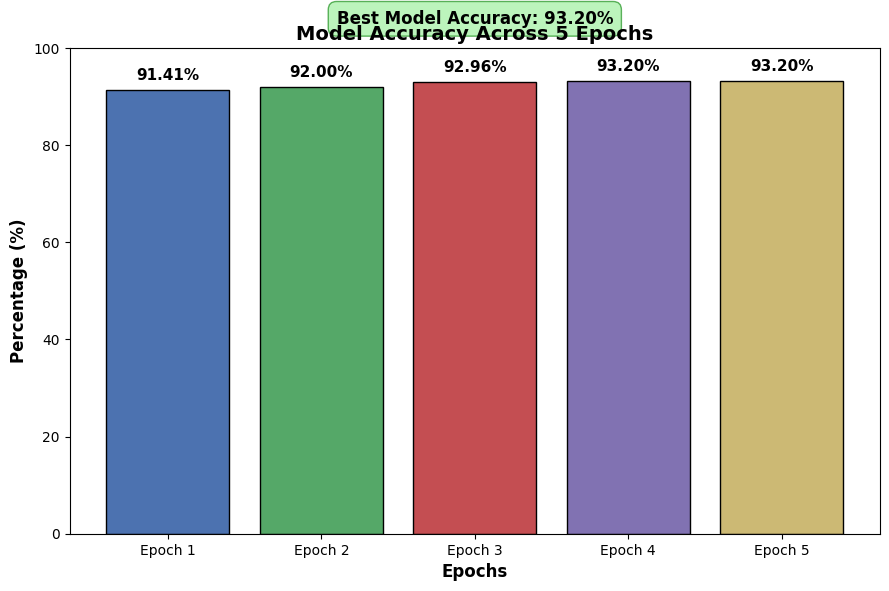

Loading the best fine-tuned model...

Overall Accuracy: 0.9319809069212410
Classification Report:
                 precision    recall  f1-score   support

        Blight       0.85      0.93      0.89       229
   Common Rust       0.98      0.97      0.98       261
Gray Leaf Spot       0.85      0.70      0.77       115
       Healthy       1.00      1.00      1.00       233

      accuracy                           0.93       838
     macro avg       0.92      0.90      0.91       838
  weighted avg       0.93      0.93      0.93       838



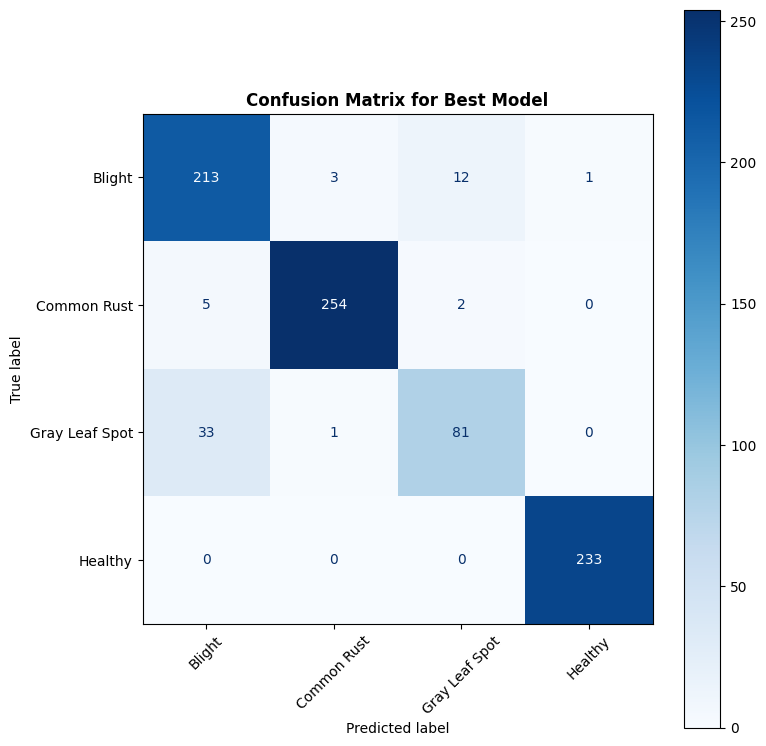

Fine-tuned model evaluation complete.


In [22]:
# ================= PLOTTING THE RESULTS =================
epochs = [f'Epoch {i+1}' for i in range(len(epoch_accuracies))]

plt.figure(figsize=(9, 6))
bars = plt.bar(epochs, epoch_accuracies, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'], edgecolor='black')

plt.ylim(0, 100)
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.title(f'Model Accuracy Across {len(epoch_accuracies)} Epochs', fontsize=14, fontweight='bold')

best_acc = max(epoch_accuracies)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.text(len(epochs)/2 - 0.5, 105, f"Best Model Accuracy: {best_acc:.2f}%", ha='center', fontsize=12, fontweight='bold', 
         bbox=dict(facecolor='lightgreen', alpha=0.6, edgecolor='green', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

# ================= EVALUATION =================
def evaluate_finetuned_model(model, dataloader, idx_to_class):
    model.eval()
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_predictions.extend([idx_to_class[p.item()] for p in predicted])
            all_true_labels.extend([idx_to_class[l.item()] for l in labels])

    accuracy = accuracy_score(all_true_labels, all_predictions)
    report = classification_report(all_true_labels, all_predictions, zero_division=0)

    print(f"\nOverall Accuracy: {accuracy:.16f}")
    print("Classification Report:\n", report)

    cm = confusion_matrix(all_true_labels, all_predictions, labels=list(idx_to_class.values()))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx_to_class.values()))
    
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
    plt.title("Confusion Matrix for Best Model", fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Loading the best fine-tuned model...")
model.load_state_dict(torch.load('best_clip_finetuned_classifier.pth'))

evaluate_finetuned_model(model, val_dataloader, idx_to_class)
print("Fine-tuned model evaluation complete.")

# ================= DICTIONARIES FOR INTERACTIVE OUTPUT =================
symptom_map = {
    "Blight": "long cigar-shaped lesions",
    "Common Rust": "reddish raised spots",
    "Gray Leaf Spot": "rectangular gray spots",
    "Healthy": "clear vibrant texture"
}

recommendations = {
    "Blight": "Apply fungicides containing Mancozeb.",
    "Common Rust": "Apply fungicides containing Pyraclostrobin.",
    "Gray Leaf Spot": "Apply fungicides containing Azoxystrobin.",
    "Healthy": "No treatment needed. Keep it up!"
}

causes_map = {
    "Blight": "Caused by the fungus Exserohilum turcicum, thriving in moderate temperatures with high humidity.",
    "Common Rust": "Caused by the fungus Puccinia sorghi, favored by cool temperatures and high relative humidity.",
    "Gray Leaf Spot": "Caused by the fungus Cercospora zeae-maydis, developing rapidly during prolonged warm, humid weather.",
    "Healthy": "Maintained by ideal soil conditions, proper irrigation, and absence of pathogenic fungi.",
    
}


In [28]:
# ================= INTERACTIVE TESTING =================
def run_test_class():
    print("Select a specific class to test:")
    print("1. Blight")
    print("2. Common Rust")
    print("3. Gray Leaf Spot")
    print("4. Healthy")
    
    choice = input("Enter the number of the class (1-4): ")
    
    class_map = {
        "1": "Blight",
        "2": "Common Rust",
        "3": "Gray Leaf Spot",
        "4": "Healthy"
    }
    
    if choice not in class_map:
        print("Invalid choice. Please run the cell again and enter a number between 1 and 4.")
        return
        
    selected_class = class_map[choice]
    print(f"\n✅ User Selected: {selected_class}")
    
    search_str = selected_class.replace(" ", "_").lower()
    class_images = [img for img in all_images if search_str in img.lower() or selected_class.lower() in img.lower()]
    
    if not class_images:
        print(f"Error: Could not find any images for '{selected_class}' in the all_images list.")
        return
        
    img_path = random.choice(class_images)
    print(f"Testing Prediction Pipeline on: {img_path}")
    
    model.load_state_dict(torch.load("best_clip_finetuned_classifier.pth"))
    model.eval()

    original_image = Image.open(img_path).convert("RGB")
    original_np = np.array(original_image)
    preprocessed_image = apply_advanced_preprocessing(original_image)
    preprocessed_np = np.array(preprocessed_image)

    pixel_values = clip_processor(
        images=preprocessed_image,
        return_tensors="pt"
    )["pixel_values"].to(device)

    with torch.no_grad():
        # 1. Linear Fine-Tuned Output
        outputs = model(pixel_values)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)
        predicted_class = idx_to_class[predicted.item()]
        conf_score = confidence.item() * 100
        
        # 2. Text Prompts / Cosine Similarity Output
        # FIXED: Use clip_model to get the projected 512-dim features
        image_features = clip_model.get_image_features(pixel_values=pixel_values)
        image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
        
        similarity = (100.0 * image_features @ text_embeddings.T).softmax(dim=-1)
        cos_probs = similarity[0]
        cos_confidence, cos_predicted = torch.max(cos_probs, 0)
        cos_predicted_class = class_names[cos_predicted.item()]
        cos_conf_score = cos_confidence.item() * 100

    symptom_text = symptom_map.get(predicted_class, "unknown symptoms")
    recommendation_text = recommendations.get(predicted_class, "No recommendation available.")
    cause_text = causes_map.get(predicted_class, "Unknown cause.")

    # Final Text Formatting displaying BOTH model logics
    if predicted_class == "Healthy":
        final_text = (
            f"Result: Predicted {conf_score:.1f}% as {predicted_class} maize leaf.\n"
            #f"CLIP Cosine Similarity: {cos_conf_score:.1f}% semantic match for {cos_predicted_class}.\n"
            f"Cause: {cause_text}\n"
            f"Reasoning: The leaf is not affected. Recommendation: {recommendation_text}"
        )
    else:
        final_text = (
            f"Result: Predicted {conf_score:.1f}% as {predicted_class} maize leaf.\n"
            #f"CLIP Cosine Similarity: {cos_conf_score:.1f}% semantic match for {cos_predicted_class}.\n"
            f"Cause: {cause_text}\n"
            f"Reasoning: It is affected since it shows {symptom_text}. Recommendation: {recommendation_text}"
        )

    print("\n" + "="*60)
    print(final_text)
    print("="*60)

    # ================= 2-PANEL OUTPUT PLOT =================
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(original_np)
    axes[0].set_title("1. Original Input Image", fontsize=12, fontweight='bold')
    axes[0].axis("off")

    axes[1].imshow(preprocessed_np)
    axes[1].set_title("2. Pre-processed (CLAHE)", fontsize=12, fontweight='bold')
    axes[1].axis("off")   

    plt.figtext(
        0.5, 0.02, 
        final_text, 
        ha="center", 
        fontsize=12, 
        fontweight='bold', 
        bbox={"facecolor": "lightblue", "alpha": 0.5, "pad": 10, "edgecolor": "steelblue"}
    )

    plt.tight_layout(rect=[0, 0.18, 1, 0.95])
    plt.show()

    # ================= AUDIO OUTPUTS =================
    print("Generating English Audio...")
    tts_en = gTTS(text=final_text, lang='en')
    fp_en = io.BytesIO()
    tts_en.write_to_fp(fp_en)
    fp_en.seek(0)
    display(Audio(fp_en.read(), autoplay=True))

    print("Generating Tamil Audio...")
    try:
        translator = Translator()
        tamil_text = translator.translate(final_text, dest='ta').text
        tts_ta = gTTS(text=tamil_text, lang='ta')
        fp_ta = io.BytesIO()
        tts_ta.write_to_fp(fp_ta)
        fp_ta.seek(0)
        display(Audio(fp_ta.read()))
    except Exception as e:
        print(f"Tamil translation skipped. Error: {e}")

Select a specific class to test:
1. Blight
2. Common Rust
3. Gray Leaf Spot
4. Healthy

✅ User Selected: Blight
Testing Prediction Pipeline on: C:\Users\acer\.cache\kagglehub\datasets\smaranjitghose\corn-or-maize-leaf-disease-dataset\versions\1\data\Blight\Corn_Blight (11).jpg

Result: Predicted 55.9% as Blight maize leaf.
Cause: Caused by the fungus Exserohilum turcicum, thriving in moderate temperatures with high humidity.
Reasoning: It is affected since it shows long cigar-shaped lesions. Recommendation: Apply fungicides containing Mancozeb.


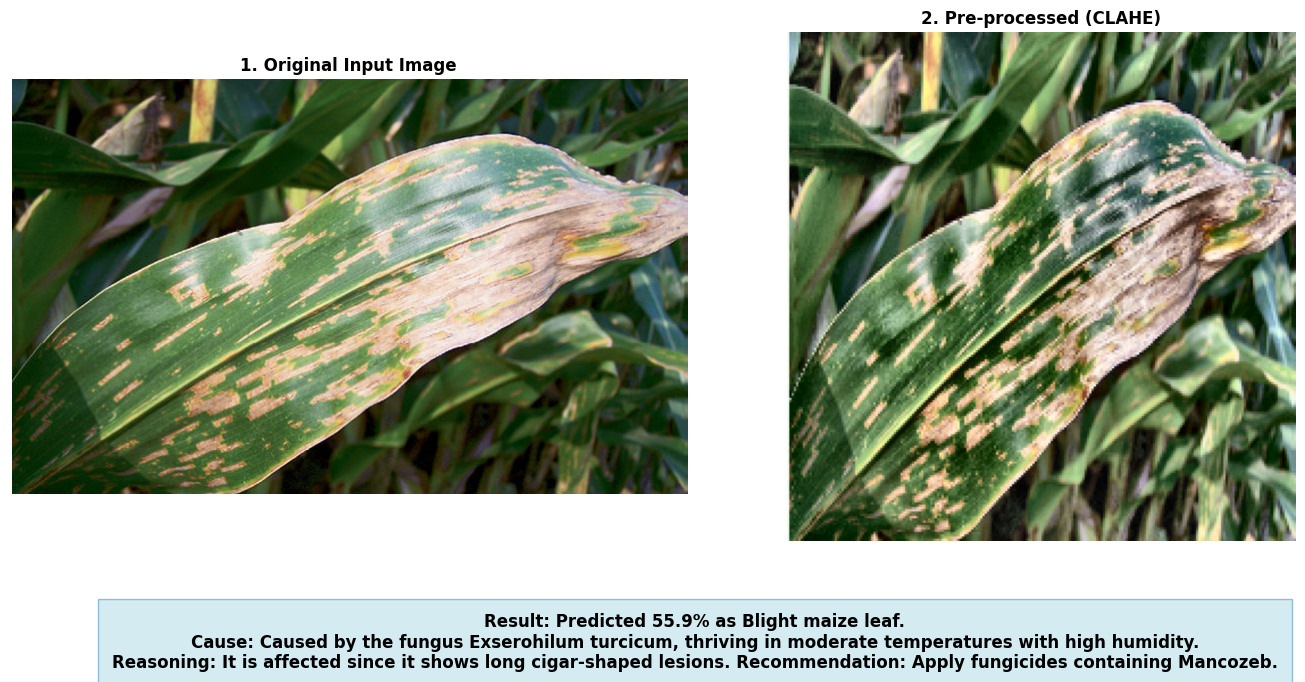

Generating English Audio...


Generating Tamil Audio...


In [30]:
run_test_class()

Select a specific class to test:
1. Blight
2. Common Rust
3. Gray Leaf Spot
4. Healthy

✅ User Selected: Common Rust
Testing Prediction Pipeline on: C:\Users\acer\.cache\kagglehub\datasets\smaranjitghose\corn-or-maize-leaf-disease-dataset\versions\1\data\Common_Rust\Corn_Common_Rust (812).JPG

Result: Predicted 100.0% as Common Rust maize leaf.
Cause: Caused by the fungus Puccinia sorghi, favored by cool temperatures and high relative humidity.
Reasoning: It is affected since it shows reddish raised spots. Recommendation: Apply fungicides containing Pyraclostrobin.


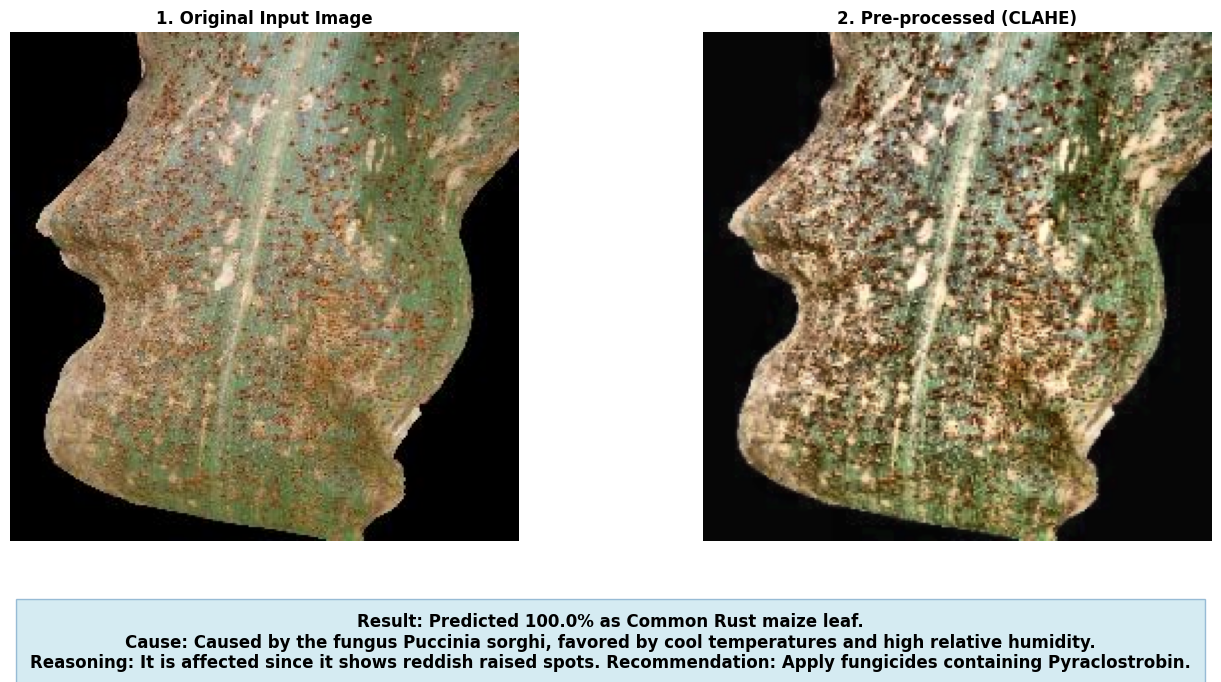

Generating English Audio...


Generating Tamil Audio...


In [31]:
run_test_class()

Select a specific class to test:
1. Blight
2. Common Rust
3. Gray Leaf Spot
4. Healthy

✅ User Selected: Gray Leaf Spot
Testing Prediction Pipeline on: C:\Users\acer\.cache\kagglehub\datasets\smaranjitghose\corn-or-maize-leaf-disease-dataset\versions\1\data\Gray_Leaf_Spot\Corn_Gray_Spot (482).JPG

Result: Predicted 81.0% as Gray Leaf Spot maize leaf.
Cause: Caused by the fungus Cercospora zeae-maydis, developing rapidly during prolonged warm, humid weather.
Reasoning: It is affected since it shows rectangular gray spots. Recommendation: Apply fungicides containing Azoxystrobin.


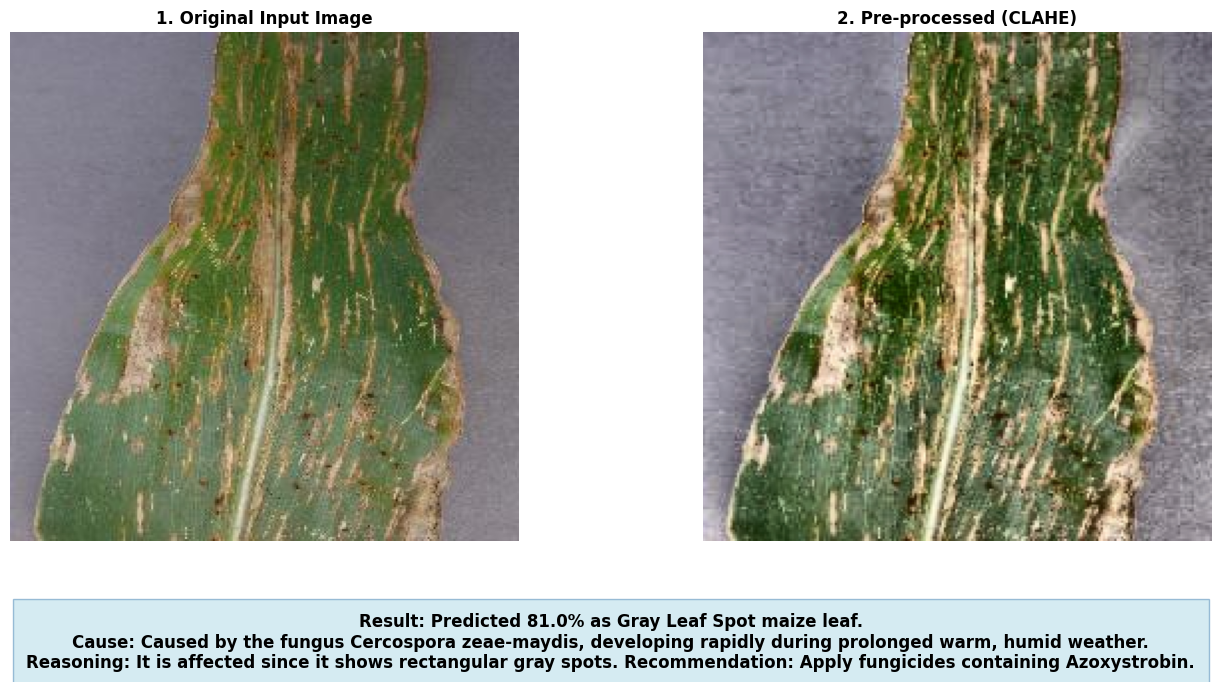

Generating English Audio...


Generating Tamil Audio...


In [32]:
run_test_class()

Select a specific class to test:
1. Blight
2. Common Rust
3. Gray Leaf Spot
4. Healthy

✅ User Selected: Healthy
Testing Prediction Pipeline on: C:\Users\acer\.cache\kagglehub\datasets\smaranjitghose\corn-or-maize-leaf-disease-dataset\versions\1\data\Healthy\Corn_Health (944).jpg

Result: Predicted 96.8% as Healthy maize leaf.
Cause: Maintained by ideal soil conditions, proper irrigation, and absence of pathogenic fungi.
Reasoning: The leaf is not affected. Recommendation: No treatment needed. Keep it up!


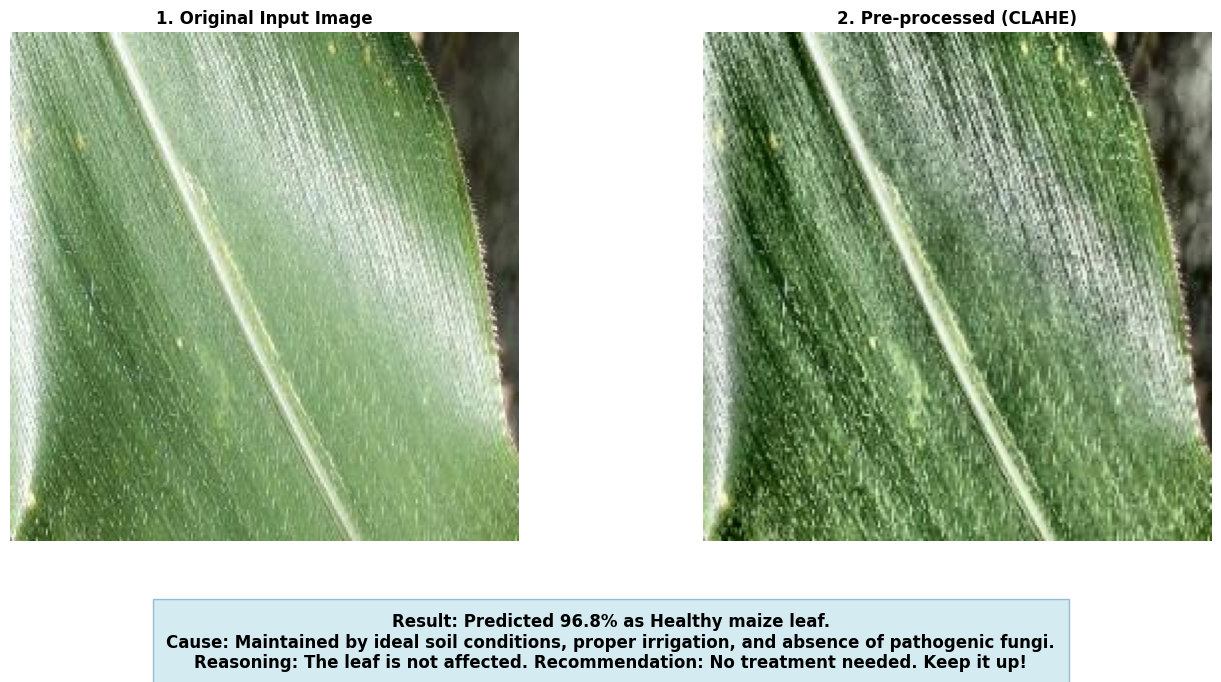

Generating English Audio...


Generating Tamil Audio...


In [33]:
run_test_class()